Gerando figuras com legendas compartilhadas...

📊 Gerando Figura 1: Métricas de Erro (RMSE + NRMSE)...
✓ Figura 1 salva: fig_error_metrics.pdf e fig_error_metrics.png


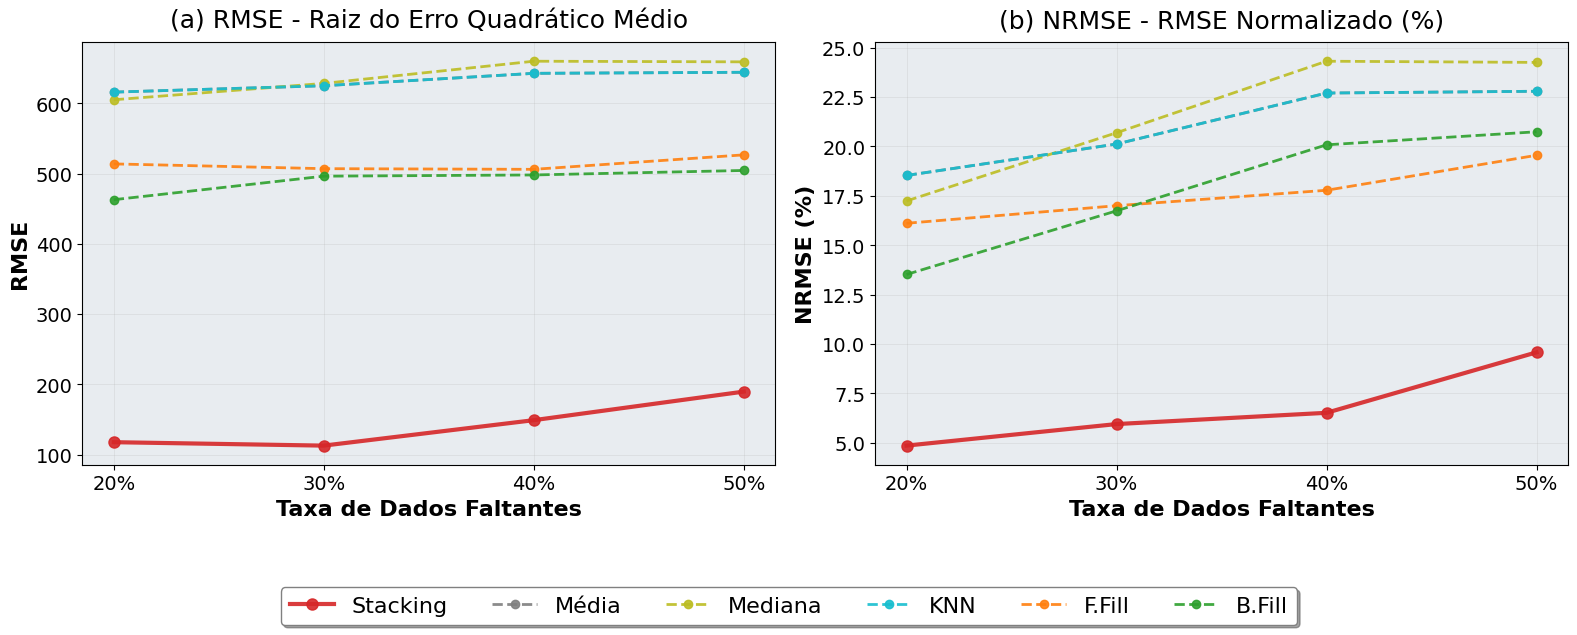


📊 Gerando Figura 2: Métricas de Qualidade (R² + MAPE)...
✓ Figura 2 salva: fig_quality_metrics.pdf e fig_quality_metrics.png


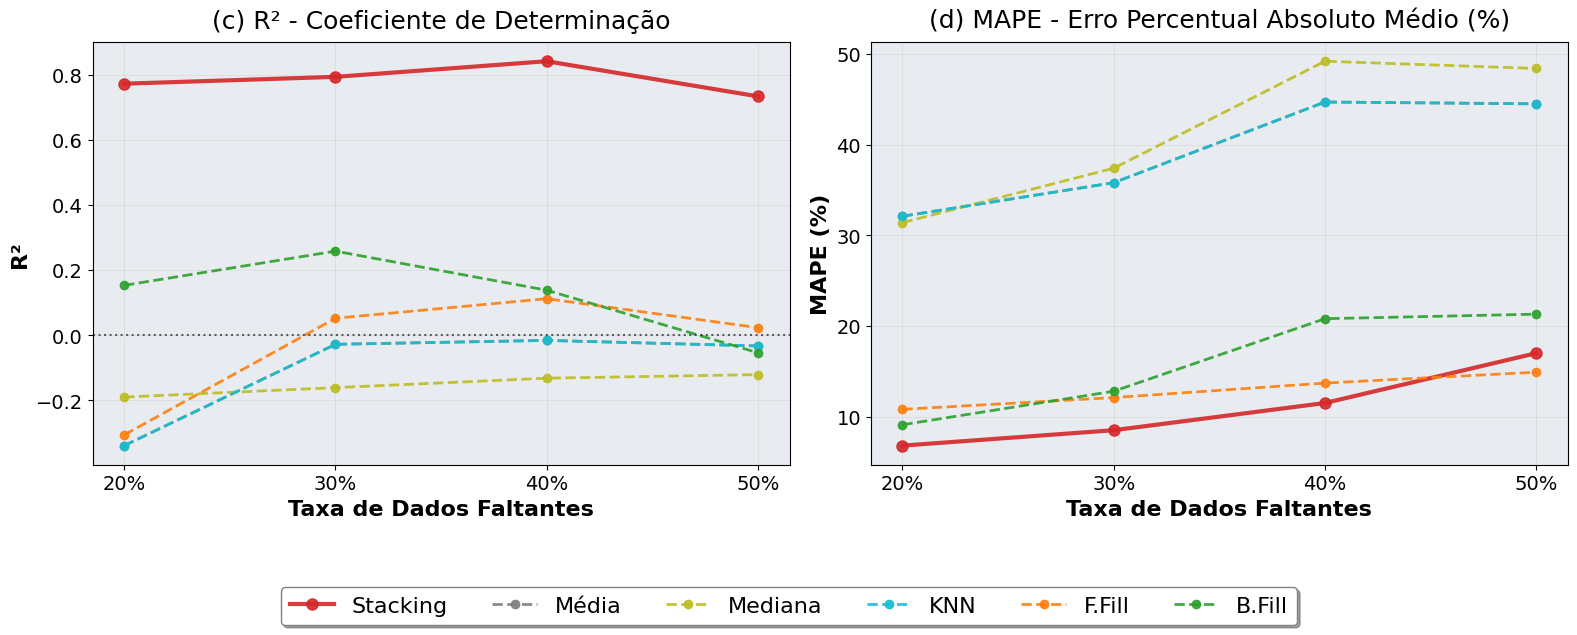


✓ Todas as figuras foram salvas com sucesso!

Arquivos gerados:
  📄 fig_error_metrics.pdf / fig_error_metrics.png
     └─ Contém: RMSE e NRMSE lado a lado

  📄 fig_quality_metrics.pdf / fig_quality_metrics.png
     └─ Contém: R² e MAPE lado a lado

💡 Cada figura tem sua legenda centralizada embaixo!
💡 Tamanho da legenda: 16pt (bem maior e mais legível)


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Configuração de estilo
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# Dados
missing_rates = ['20%', '30%', '40%', '50%']
methods = ['Stacking', 'Média', 'Mediana', 'KNN', 'F.Fill', 'B.Fill']

# Métricas
rmse = {
    'Stacking': [117.72, 112.85, 149.05, 189.70],
    'Média': [615.92, 625.00, 642.65, 644.15],
    'Mediana': [605.01, 628.32, 659.89, 658.99],
    'KNN': [615.92, 625.00, 642.65, 644.15],
    'F.Fill': [513.76, 506.98, 506.03, 526.63],
    'B.Fill': [462.81, 496.30, 498.03, 504.43]
}

nrmse = {
    'Stacking': [4.86, 5.95, 6.52, 9.58],
    'Média': [18.53, 20.12, 22.70, 22.79],
    'Mediana': [17.24, 20.69, 24.31, 24.25],
    'KNN': [18.53, 20.12, 22.70, 22.79],
    'F.Fill': [16.11, 17.00, 17.78, 19.55],
    'B.Fill': [13.52, 16.74, 20.08, 20.74]
}

r2 = {
    'Stacking': [0.772, 0.793, 0.841, 0.733],
    'Média': [-0.339, -0.028, -0.016, -0.033],
    'Mediana': [-0.190, -0.161, -0.132, -0.121],
    'KNN': [-0.339, -0.028, -0.016, -0.033],
    'F.Fill': [-0.306, 0.052, 0.112, 0.023],
    'B.Fill': [0.153, 0.258, 0.138, -0.054]
}

mape = {
    'Stacking': [6.8, 8.5, 11.5, 17.0],
    'Média': [32.1, 35.8, 44.7, 44.5],
    'Mediana': [31.4, 37.4, 49.2, 48.4],
    'KNN': [32.1, 35.8, 44.7, 44.5],
    'F.Fill': [10.8, 12.1, 13.7, 14.9],
    'B.Fill': [9.1, 12.8, 20.8, 21.3]
}

# Cores e estilos
colors = {
    'Stacking': '#d62728',  # Vermelho
    'Média': '#7f7f7f',      # Cinza
    'Mediana': '#bcbd22',    # Verde-amarelo
    'KNN': '#17becf',       # Ciano
    'F.Fill': '#ff7f0e',    # Laranja
    'B.Fill': '#2ca02c'     # Verde
}

# ============================================================================
# FIGURA 1: RMSE e NRMSE com legenda compartilhada embaixo
# ============================================================================
def plot_error_metrics():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    metrics_data = [
        (rmse, 'RMSE', '(a) RMSE - Raiz do Erro Quadrático Médio', axes[0]),
        (nrmse, 'NRMSE (%)', '(b) NRMSE - RMSE Normalizado (%)', axes[1])
    ]
    
    # Plotar cada métrica
    for data, ylabel, title, ax in metrics_data:
        for method in methods:
            linestyle = '-' if method == 'Stacking' else '--'
            linewidth = 3 if method == 'Stacking' else 2
            marker = 'o'
            markersize = 8 if method == 'Stacking' else 6
            
            ax.plot(missing_rates, data[method], marker=marker, 
                   linestyle=linestyle, linewidth=linewidth,
                   markersize=markersize, label=method, 
                   color=colors[method], alpha=0.9)
        
        ax.set_xlabel('Taxa de Dados Faltantes', fontsize=16, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=16, fontweight='bold')
        ax.set_title(title, fontsize=18, pad=10)
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax.set_facecolor('#e8ecf0')
    
    # Criar legenda compartilhada EMBAIXO
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, 
              loc='lower center', 
              bbox_to_anchor=(0.5, -0.08),
              ncol=6,
              fontsize=16,
              frameon=True,
              fancybox=True,
              shadow=True,
              edgecolor='gray')
    
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.savefig('fig_error_metrics.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('fig_error_metrics.png', dpi=300, bbox_inches='tight')
    print("✓ Figura 1 salva: fig_error_metrics.pdf e fig_error_metrics.png")
    plt.show()

# ============================================================================
# FIGURA 2: R² e MAPE com legenda compartilhada embaixo
# ============================================================================
def plot_quality_metrics():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    metrics_data = [
        (r2, 'R²', '(c) R² - Coeficiente de Determinação', axes[0]),
        (mape, 'MAPE (%)', '(d) MAPE - Erro Percentual Absoluto Médio (%)', axes[1])
    ]
    
    # Plotar cada métrica
    for data, ylabel, title, ax in metrics_data:
        for method in methods:
            linestyle = '-' if method == 'Stacking' else '--'
            linewidth = 3 if method == 'Stacking' else 2
            marker = 'o'
            markersize = 8 if method == 'Stacking' else 6
            
            ax.plot(missing_rates, data[method], marker=marker, 
                   linestyle=linestyle, linewidth=linewidth,
                   markersize=markersize, label=method, 
                   color=colors[method], alpha=0.9)
        
        ax.set_xlabel('Taxa de Dados Faltantes', fontsize=16, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=16, fontweight='bold')
        ax.set_title(title, fontsize=18, pad=10)
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
        ax.set_facecolor('#e8ecf0')
        
        # Adicionar linha horizontal em y=0 apenas no gráfico R²
        if ylabel == 'R²':
            ax.axhline(y=0, color='k', linestyle=':', linewidth=1.5, alpha=0.6)
    
    # Criar legenda compartilhada EMBAIXO
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, 
              loc='lower center', 
              bbox_to_anchor=(0.5, -0.08),
              ncol=6,
              fontsize=16,
              frameon=True,
              fancybox=True,
              shadow=True,
              edgecolor='gray')
    
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.savefig('fig_quality_metrics.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('fig_quality_metrics.png', dpi=300, bbox_inches='tight')
    print("✓ Figura 2 salva: fig_quality_metrics.pdf e fig_quality_metrics.png")
    plt.show()

# ============================================================================
# EXECUTAR AMBAS AS FIGURAS
# ============================================================================
if __name__ == "__main__":
    print("="*70)
    print("Gerando figuras com legendas compartilhadas...")
    print("="*70)
    
    print("\n📊 Gerando Figura 1: Métricas de Erro (RMSE + NRMSE)...")
    plot_error_metrics()
    
    print("\n📊 Gerando Figura 2: Métricas de Qualidade (R² + MAPE)...")
    plot_quality_metrics()
    
    print("\n" + "="*70)
    print("✓ Todas as figuras foram salvas com sucesso!")
    print("="*70)
    print("\nArquivos gerados:")
    print("  📄 fig_error_metrics.pdf / fig_error_metrics.png")
    print("     └─ Contém: RMSE e NRMSE lado a lado")
    print("\n  📄 fig_quality_metrics.pdf / fig_quality_metrics.png")
    print("     └─ Contém: R² e MAPE lado a lado")
    print("\n💡 Cada figura tem sua legenda centralizada embaixo!")
    print("💡 Tamanho da legenda: 16pt (bem maior e mais legível)")
    print("="*70)

✓ Gráfico salvo com sucesso!


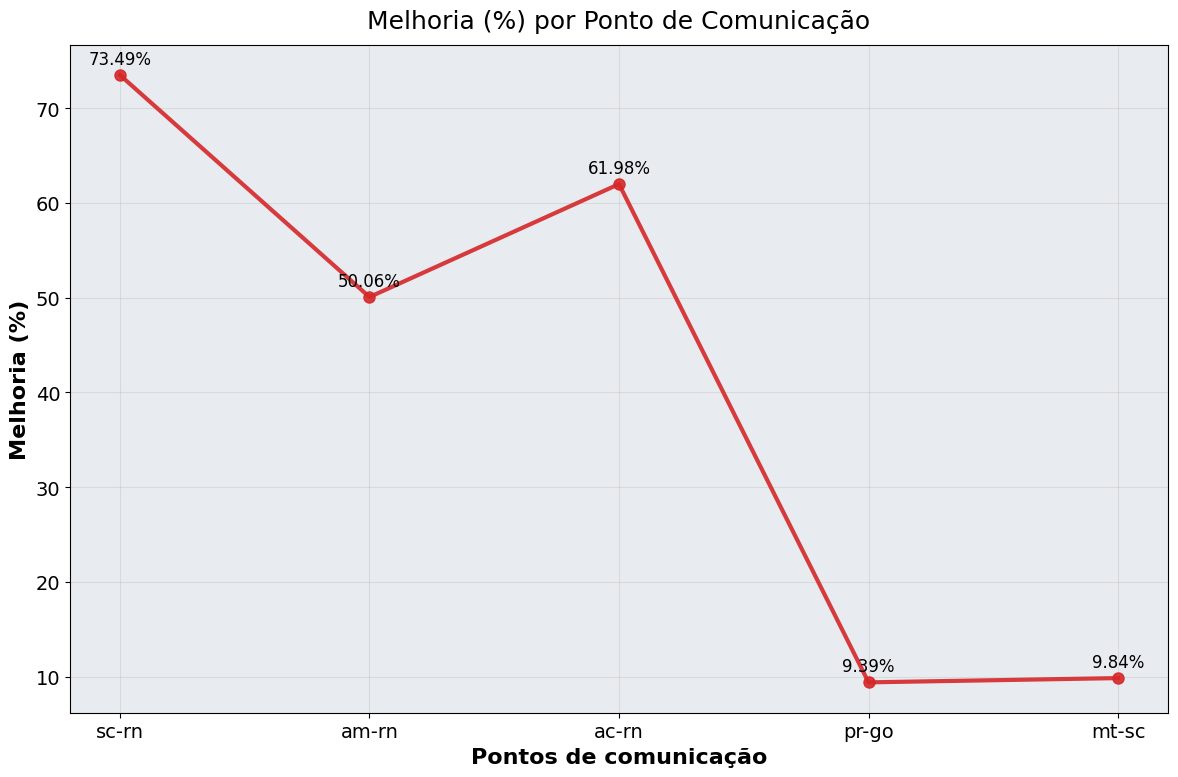

In [3]:
import matplotlib.pyplot as plt

# ============================================================================
# ESTILO PADRÃO (mesmo dos gráficos anteriores)
# ============================================================================
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

# ============================================================================
# DADOS ORIGINAIS DO SEU GRÁFICO
# ============================================================================
points = ['sc-rn', 'am-rn', 'ac-rn', 'pr-go', 'mt-sc']
improvement = [73.49, 50.06, 61.98, 9.39, 9.84]

# ============================================================================
# GRÁFICO COM ESTÉTICA PADRONIZADA
# ============================================================================
def plot_improvement_by_link():
    fig, ax = plt.subplots(figsize=(12, 8))

    ax.plot(
        points,
        improvement,
        marker='o',
        linestyle='-',
        linewidth=3,
        markersize=8,
        color='#d62728',   # mesma cor de destaque usada antes para o Stacking
        alpha=0.9
    )

    # Anotações dos valores
    for x, y in zip(points, improvement):
        ax.annotate(
            f'{y:.2f}%',
            xy=(x, y),
            xytext=(0, 8),
            textcoords='offset points',
            ha='center',
            fontsize=12
        )

    ax.set_title('Melhoria (%) por Ponto de Comunicação', fontsize=18, pad=12)
    ax.set_xlabel('Pontos de comunicação', fontsize=16, fontweight='bold')
    ax.set_ylabel('Melhoria (%)', fontsize=16, fontweight='bold')

    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#e8ecf0')

    plt.tight_layout()
    plt.savefig('fig_improvement_links.pdf', dpi=300, bbox_inches='tight')
    plt.savefig('fig_improvement_links.png', dpi=300, bbox_inches='tight')
    print("✓ Gráfico salvo com sucesso!")
    plt.show()

# ============================================================================
# EXECUÇÃO
# ============================================================================
if __name__ == "__main__":
    plot_improvement_by_link()